# Efficiency Frontier — results explorer

Live companion to `PLAN.md`: **Run All to refresh as stage outputs land.** Every stage cell
guards on its output file existing, so the notebook runs cleanly at any point of the campaign
and simply reports which stages are still pending.

**Scope ruling (George, 2026-08-25): quantum-computing work only.** Classical
post-processing (the hit-uniqueness post-selection gate — a prior separate study) is out of
scope: no composed points, no gate arms. Every number here is a property of the quantum
filter p(A) alone.

**Conventions (house rules that bite here):**
- Frontier columns are **matched-efficiency** working points (τ at the k-th true amplitude, the XII convention) — never judge the normalized ±½ or fitted families at fixed τ=0.35 (amplitude-convention artifact; their fixed-τ ~0.5 is expected).
- Every operating degree carries its **d & d+4 twin**; a pair disagreeing by >1 % eff is UNSTABLE (open markers below), per the BE-05 ripple rule.
- `far = n_false_active / n_active`; targets: moderate **eff ≥ 0.995 @ far ≤ 0.01**, heavy Pareto vs the **XII fitted response (far 0.061–0.096 at eff 0.97–0.98)**.

Data provenance: `outputs/*.csv` (committed) + `outputs/cache/01_amps_*.npz` (local amplitude caches, regenerate with `01_degree_response_frontier.py`).

In [1]:
%matplotlib inline
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Efficiency_Frontier")
OUT, CACHE = HERE / "outputs", HERE / "outputs" / "cache"

# house palette — color follows the FAMILY, fixed everywhere (never re-cycled)
FAM_COL = {
    "classical_invA":       "#52514e",
    "1bqf_cos":             "#e34948",
    "comb_prod":            "#4a3aa7",
    "band_inverse":         "#2a78d6",
    "sharp_comb":           "#8a63d2",
    "normalized_half_comb": "#eb6834",
    "fitted_ridge":         "#1baf7a",
    "fitted_binned":        "#0d7a52",
    "fitted_xval":          "#7fc7a8",
    "fitted_moment":        "#1baf7a",
}
FAM_LAB = {
    "classical_invA": "classical 1/λ", "1bqf_cos": "1BQF cos",
    "comb_prod": "comb hw0.18", "band_inverse": "band inverse",
    "sharp_comb": "sharp hw0.06", "normalized_half_comb": "normalized ±½",
    "fitted_ridge": "fitted (Cheb.)", "fitted_binned": "fitted (binned)",
    "fitted_xval": "fitted (x-val)", "fitted_moment": "fitted (moment)",
}

STAGES = {
    "0 inventory":  ["00_inventory.csv", "00_gap_list.csv"],
    "1 degree×response": ["01_frontier_clean_moderate.csv"],
    "2 set-outs":   ["02_setout_frontier.csv"],
    "1+2 high-T":   ["03_highT_frontier.csv", "03_1bqf_reference.csv"],
    "3 heavy+loss": ["04_heavy_frontier.csv", "05_loss_budget.csv"],
    "4 confirmation": ["06_confirmation.csv"],
}

def load(name):
    p = OUT / name
    return pd.read_csv(p) if p.exists() else None

print(f"status @ {time.strftime('%Y-%m-%d %H:%M')}")
for stage, files in STAGES.items():
    for f in files:
        p = OUT / f
        if p.exists():
            df_ = pd.read_csv(p)
            print(f"  [x] {stage:18s} {f:32s} {len(df_):>6} rows   "
                  f"{time.strftime('%m-%d %H:%M', time.localtime(p.stat().st_mtime))}")
        else:
            print(f"  [ ] {stage:18s} {f:32s} — not yet produced")
caches = sorted(CACHE.glob("01_amps_*.npz"))
print(f"  amplitude caches: {len(caches)} "
      f"({', '.join(c.stem.replace('01_amps_', '') for c in caches)})")

status @ 2026-08-26 13:36
  [x] 0 inventory        00_inventory.csv                  38011 rows   08-24 14:54
  [x] 0 inventory        00_gap_list.csv                      76 rows   08-24 14:54
  [x] 1 degree×response  01_frontier_clean_moderate.csv     1018 rows   08-24 15:38
  [x] 2 set-outs         02_setout_frontier.csv              860 rows   08-24 18:49
  [x] 1+2 high-T         03_highT_frontier.csv               296 rows   08-25 00:42
  [x] 1+2 high-T         03_1bqf_reference.csv                43 rows   08-24 23:05
  [x] 3 heavy+loss       04_heavy_frontier.csv               360 rows   08-26 12:37
  [x] 3 heavy+loss       05_loss_budget.csv                 1070 rows   08-26 12:42
  [ ] 4 confirmation     06_confirmation.csv              — not yet produced
  amplitude caches: 20 (clean_rep0, clean_rep1, clean_rep2, clean_rep3, clean_rep4, clean_rep5, clean_rep6, clean_rep7, clean_rep8, clean_rep9, moderate_rep0, moderate_rep1, moderate_rep2, moderate_rep3, moderate_rep4, modera

## Stage 0 — inventory coverage & the frozen gap list

In [2]:
inv, gaps = load("00_inventory.csv"), load("00_gap_list.csv")
if inv is None:
    print("Stage 0 not yet produced")
else:
    inv["regime_c"] = inv["regime"].where(~inv["regime"].str.startswith("other("),
                                          "other (robustness axes)")
    display(inv.pivot_table(index="response_family", columns="regime_c",
                            values="eff", aggfunc="count", fill_value=0))
    print("gap list:", dict(gaps["status"].value_counts()))
    display(gaps[gaps.status != "missing"].head(20))

regime_c,clean,clean+drop1%,heavy,moderate,other (robustness axes)
response_family,,,,,
1bqf_cos,3312,408,63,448,6768
classical_invA,4825,2190,146,2565,12760
comb_prod,1120,554,67,448,1864
fitted_cheb,0,0,81,0,0
fitted_ridge,0,0,334,0,0
fitted_ridge_xval,0,0,30,0,0
normalized_half_comb,24,0,0,0,0


gap list: {'missing': np.int64(62), 'covered': np.int64(11), 'partial': np.int64(3)}


,regime,T,response_family,degree,reps_have,reps_needed,status,notes
0,clean,200,comb_prod,8,3,3,covered,S1 production comb
1,clean,200,comb_prod,12,3,3,covered,S1 production comb
2,clean,200,comb_prod,16,3,3,covered,S1 production comb
3,clean,200,comb_prod,20,3,3,covered,S1 production comb
4,clean,200,comb_prod,24,3,3,covered,S1 production comb
5,clean,200,comb_prod,28,3,3,covered,S1 production comb
6,clean,200,comb_prod,32,3,3,covered,S1 production comb
7,clean,200,comb_prod,40,10,3,covered,S1 production comb
25,clean,200,normalized_half_comb,12,1,3,partial,S1 normalized +-1/2 comb
26,clean,200,normalized_half_comb,20,1,3,partial,S1 normalized +-1/2 comb


## Stage 1 — degree scan per QSVT family

QSVT families only (classical/1BQF baselines live in the CSV, not the plots). **Per-rep dots
with a median line** — no mean±std bars: the floor population is a small-count event property
(1–3 % of trues per rep), so rep scatter is physics, and far@matched-eff is bimodal
(flood / no-flood), where a std bar is meaningless. Right panel is the **rejection factor**
1/far at matched eff 0.99 (log axis; capped at the finite-sample resolution ≈ n_active).
Open markers = the d/d+4 stability stamp FAILED (>1 % eff disagreement with the twin).

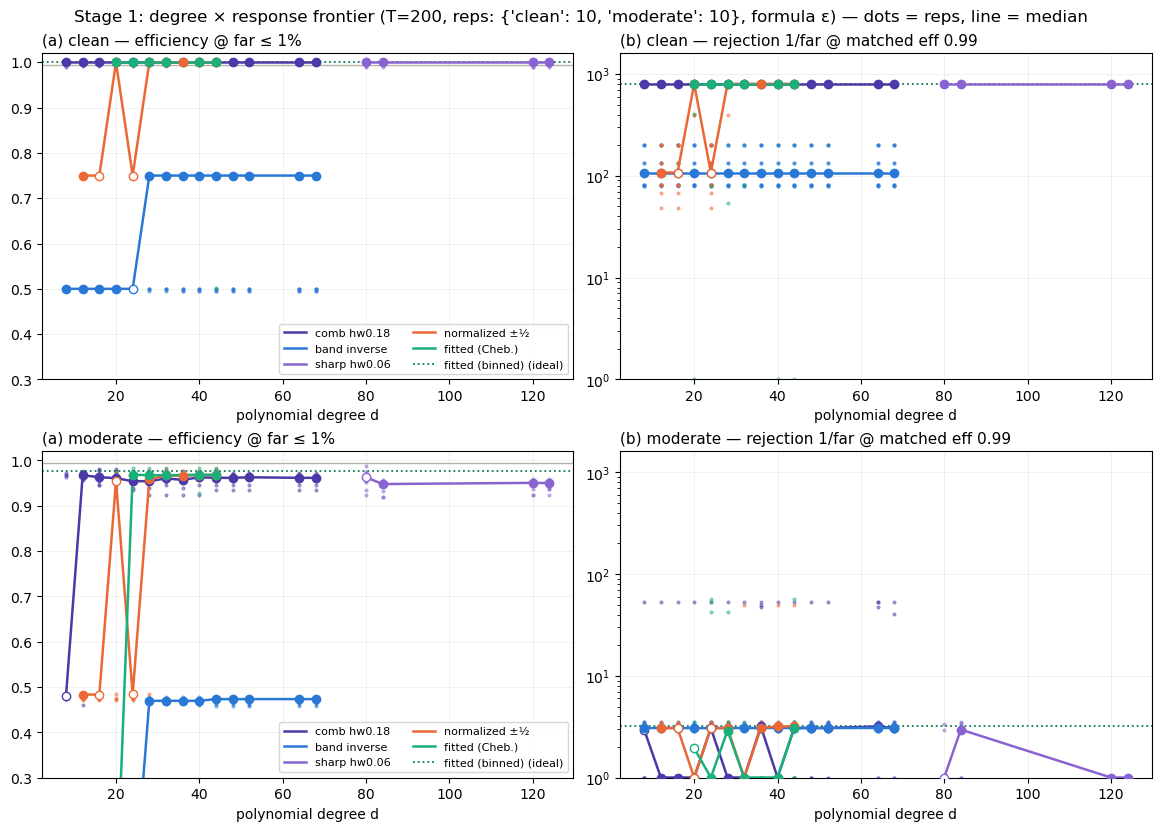

In [3]:
f1 = load("01_frontier_clean_moderate.csv")
if f1 is None:
    print("Stage 1 not yet produced")
else:
    QSVT_FAMS = ["comb_prod", "band_inverse", "sharp_comb",
                 "normalized_half_comb", "fitted_ridge"]
    REJ_CAP = 800.0                      # ~n_active: finite-sample resolution
    rej = lambda far: 1.0 / np.maximum(np.asarray(far, float), 1.0 / REJ_CAP)
    regimes = [r for r in ["clean", "moderate", "heavy"] if (f1.regime == r).any()]
    fig, axes = plt.subplots(len(regimes), 2, figsize=(11.5, 4.1 * len(regimes)),
                             constrained_layout=True)
    axes = np.atleast_2d(axes)
    for i, rg in enumerate(regimes):
        sub = f1[f1.regime == rg]
        for j in (0, 1):
            ax = axes[i, j]
            for fam in QSVT_FAMS:
                sf = sub[sub.family == fam].dropna(subset=["degree"])
                if not len(sf):
                    continue
                yv = sf["eff_f010"] if j == 0 else rej(sf["far_e990"])
                ax.plot(sf["degree"], yv, ".", ms=4, alpha=0.45,
                        color=FAM_COL[fam], zorder=2)
                med = (pd.DataFrame({"d": sf["degree"], "y": yv})
                       .groupby("d")["y"].median())
                ax.plot(med.index, med.values, "-", lw=1.8, color=FAM_COL[fam],
                        zorder=3, label=FAM_LAB[fam])
                # d/d+4 stability stamp on the efficiency median
                eff_med = sf.groupby("degree")["eff_f010"].median()
                for d in med.index:
                    tw = eff_med.get(d + 4)
                    unstable = tw is not None and abs(eff_med[d] - tw) > 0.01
                    ax.plot([d], [med[d]], "o", ms=6, color=FAM_COL[fam],
                            mfc="white" if unstable else FAM_COL[fam], zorder=4)
            ideal = sub[sub.family == "fitted_binned"]
            if len(ideal):
                ref = (ideal["eff_f010"].median() if j == 0
                       else float(np.median(rej(ideal["far_e990"]))))
                ax.axhline(ref, color=FAM_COL["fitted_binned"], ls=":", lw=1.3,
                           label=FAM_LAB["fitted_binned"] + " (ideal)")
            if j == 0:
                ax.axhline(0.995, color="#b7b3a8", lw=1, zorder=0)
                ax.set_ylim(0.3, 1.02)
                ax.set_title(f"(a) {rg} — efficiency @ far ≤ 1%", loc="left",
                             fontsize=11)
            else:
                ax.set_yscale("log")
                ax.set_ylim(1, 2 * REJ_CAP)
                ax.set_title(f"(b) {rg} — rejection 1/far @ matched eff 0.99",
                             loc="left", fontsize=11)
            ax.set_xlabel("polynomial degree d")
            ax.grid(alpha=0.25, lw=0.5)
        axes[i, 0].legend(fontsize=8, ncol=2, loc="lower right")
    n_reps = f1.groupby("regime")["rep"].nunique().to_dict()
    fig.suptitle(f"Stage 1: degree × response frontier (T=200, reps: {n_reps}, "
                 "formula ε) — dots = reps, line = median", fontsize=12)
    plt.show()

## Stage 1 — rejection curves (efficiency vs 1/false-rate)

The HEP presentation: signal efficiency on x, background **rejection factor 1/far** on log y —
the near-zero-far region becomes visible separation instead of curves piled on the axis.
Where a threshold admits zero false actives the rejection is capped at n_active (the
finite-sample resolution) — flat tops at the cap mean "no fake seen", not saturation.
QSVT families only; all reps overlaid (thin lines). Grey crosshair = target (eff 0.995,
rejection 100 ⇔ far 1%).

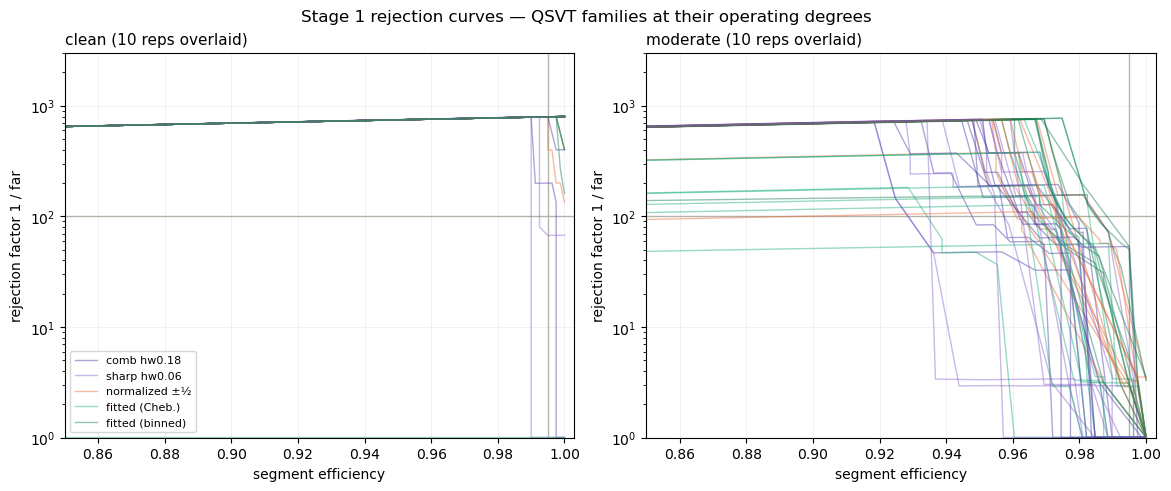

In [4]:
def rejection_curve(x, truth, npts=1200):
    """(efficiency, rejection) along the threshold sweep; rejection = n_active /
    max(n_false_active, 1) — when no fake is admitted this equals n_active, the
    finite-sample resolution cap."""
    x = np.abs(np.asarray(x, float)); truth = np.asarray(truth, bool)
    n_true = truth.sum()
    taus = np.quantile(np.unique(x[truth]), np.linspace(0, 1, min(npts, n_true)))[::-1]
    xs, xt = np.sort(x), np.sort(x[truth])
    nact = len(x) - np.searchsorted(xs, taus, side="left")
    ntru = n_true - np.searchsorted(xt, taus, side="left")
    return ntru / n_true, nact / np.maximum(nact - ntru, 1)

SHOW = ["comb_prod_d40", "sharp_comb_d80", "normalized_half_comb_d44",
        "fitted_ridge_d40", "fitted_binned_dnan"]
caches = {p.stem.replace("01_amps_", ""): p for p in sorted(CACHE.glob("01_amps_*.npz"))}
if not caches:
    print("no amplitude caches — run 01_degree_response_frontier.py")
else:
    regs = sorted({k.rsplit("_rep", 1)[0] for k in caches})
    reps = sorted({int(k.rsplit("_rep", 1)[1]) for k in caches})
    fig, axes = plt.subplots(1, len(regs), figsize=(5.8 * len(regs), 4.8),
                             constrained_layout=True, squeeze=False)
    for ax, rg in zip(axes[0], regs):
        for rep in reps:
            key = f"{rg}_rep{rep}"
            if key not in caches:
                continue
            z = np.load(caches[key])
            truth = z["truth"]
            for name in SHOW:
                if name not in z.files:
                    continue
                fam = name.rsplit("_d", 1)[0]
                e, r = rejection_curve(z[name], truth)
                ax.plot(e, r, color=FAM_COL[fam], lw=1.0, alpha=0.45,
                        label=FAM_LAB[fam] if rep == reps[0] else None)
        ax.axvline(0.995, color="#b7b3a8", lw=1, zorder=0)
        ax.axhline(100, color="#b7b3a8", lw=1, zorder=0)
        ax.set_yscale("log"); ax.set_xlim(0.85, 1.003); ax.set_ylim(1, 3e3)
        ax.set_xlabel("segment efficiency")
        ax.set_ylabel("rejection factor 1 / far")
        ax.set_title(f"{rg} ({len(reps)} reps overlaid)", loc="left", fontsize=11)
        ax.grid(alpha=0.25, lw=0.5)
    axes[0, 0].legend(fontsize=8, loc="lower left")
    fig.suptitle("Stage 1 rejection curves — QSVT families at their operating degrees",
                 fontsize=12)
    plt.show()

## Stage 1 — amplitude spectra (where the floor lives)

True vs false amplitude pile-up for a chosen config; change `PICK` freely. The moderate
true population's low-amplitude tail (fragments/twins) is the ~3 % that no response recovers.

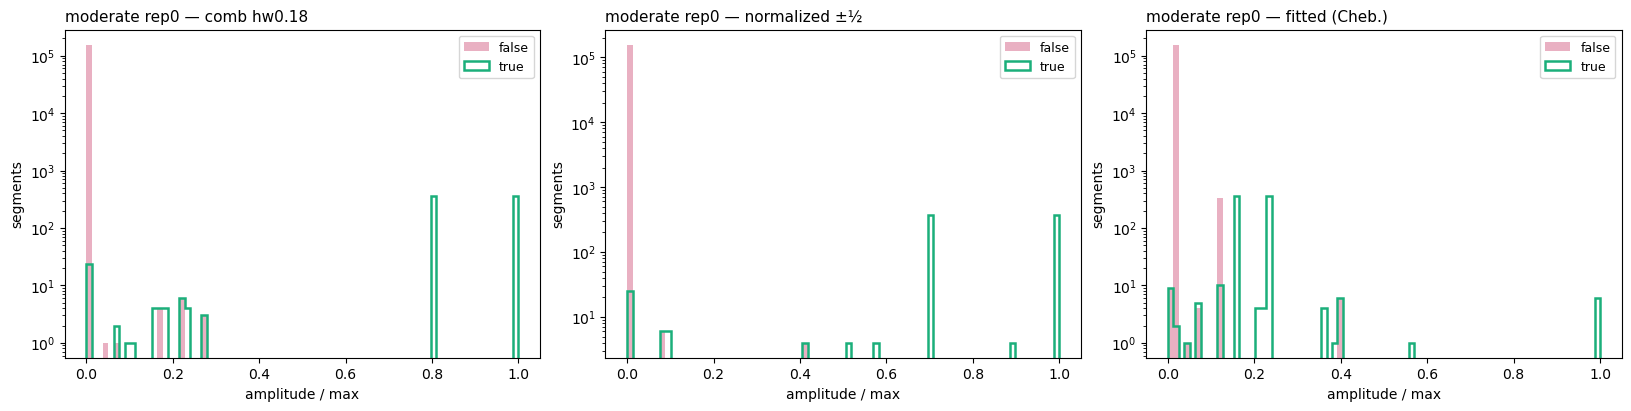

In [5]:
PICK = [("moderate", 0, "comb_prod_d40"),
        ("moderate", 0, "normalized_half_comb_d44"),
        ("moderate", 0, "fitted_ridge_d40")]
avail = [(rg, rep, key) for (rg, rep, key) in PICK
         if (CACHE / f"01_amps_{rg}_rep{rep}.npz").exists()]
if not avail:
    print("no amplitude caches — run 01_degree_response_frontier.py")
else:
    fig, axes = plt.subplots(1, len(avail), figsize=(5.4 * len(avail), 4.0),
                             constrained_layout=True, squeeze=False)
    for ax, (rg, rep, key) in zip(axes[0], avail):
        z = np.load(CACHE / f"01_amps_{rg}_rep{rep}.npz")
        if key not in z.files:
            ax.set_title(f"{key} not in cache"); continue
        x = np.abs(z[key]).astype(float); truth = z["truth"].astype(bool)
        x = x / max(x.max(), 1e-30)
        bins = np.linspace(0, 1, 80)
        ax.hist(x[~truth], bins=bins, color="#e9b0c2", label="false", log=True)
        ax.hist(x[truth], bins=bins, histtype="step", lw=1.8, color="#1baf7a",
                label="true", log=True)
        fam = key.rsplit("_d", 1)[0]
        ax.set_title(f"{rg} rep{rep} — {FAM_LAB.get(fam, fam)}", loc="left", fontsize=11)
        ax.set_xlabel("amplitude / max"); ax.set_ylabel("segments")
        ax.legend(fontsize=9)
    plt.show()

## Stage 2 — Hamiltonian set-outs (auto-loads when produced)

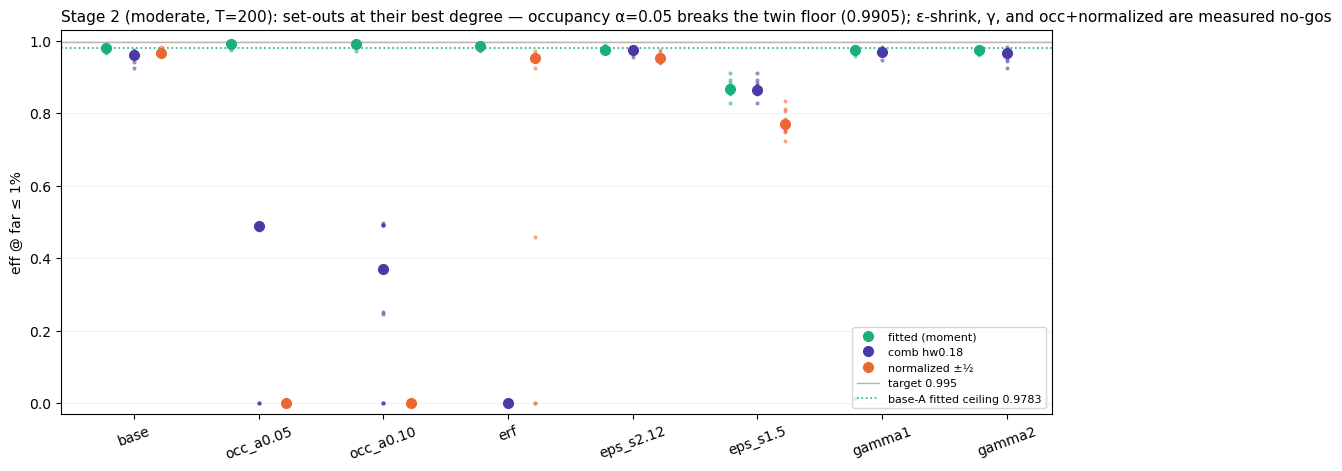

,regime,family,degree,setout,occ_alpha,eps_scale,gamma,kernel,fork_beta,eff_f010,far_e995
4,clean,fitted_moment,40.0,fork_b0.5,0.00,3.0,3.0,step,0.5,1.0000,0.0000
3,clean,fitted_moment,32.0,fork_b0.5,0.00,3.0,3.0,step,0.5,1.0000,0.0000
5,clean,fitted_moment,44.0,fork_b0.5,0.00,3.0,3.0,step,0.5,1.0000,0.0000
8,clean,normalized_half_comb,40.0,fork_b0.5,0.00,3.0,3.0,step,0.5,1.0000,0.0003
7,clean,fitted_moment,160.0,fork_b0.5,0.00,3.0,3.0,step,0.5,1.0000,0.0000
6,clean,fitted_moment,80.0,fork_b0.5,0.00,3.0,3.0,step,0.5,1.0000,0.0000
9,clean,normalized_half_comb,44.0,fork_b0.5,0.00,3.0,3.0,step,0.5,1.0000,0.0003
2,clean,comb_prod,44.0,fork_b0.5,0.00,3.0,3.0,step,0.5,0.9995,0.0001
0,clean,classical_invA,NaN,fork_b0.5,0.00,3.0,3.0,step,0.5,0.9995,0.0003
1,clean,comb_prod,40.0,fork_b0.5,0.00,3.0,3.0,step,0.5,0.9995,0.0001


In [6]:
f2 = load("02_setout_frontier.csv")
if f2 is None:
    print("Stage 2 not yet produced")
else:
    d2 = f2[f2.family != "classical_invA"].copy()
    d2["degree"] = pd.to_numeric(d2["degree"], errors="coerce")
    mod = d2[d2.regime == "moderate"]
    ORDER = [s for s in ["base", "occ_a0.05", "occ_a0.10", "erf",
                         "eps_s2.12", "eps_s1.5", "gamma1", "gamma2"]
             if s in set(mod.setout)]
    FAMS = ["fitted_moment", "comb_prod", "normalized_half_comb"]
    OFF = {"fitted_moment": -0.22, "comb_prod": 0.0,
           "normalized_half_comb": 0.22}
    fig, ax = plt.subplots(figsize=(10.5, 4.6), constrained_layout=True)
    for fam in FAMS:
        xs, ys = [], []
        for i, st in enumerate(ORDER):
            sg = mod[(mod.setout == st) & (mod.family == fam)]
            if not len(sg):
                continue
            med = sg.groupby("degree")["eff_f010"].median()
            dbest = med.idxmax()
            reps = sg[sg.degree == dbest]["eff_f010"]
            ax.plot([i + OFF[fam]] * len(reps), reps, ".", ms=4, alpha=0.45,
                    color=FAM_COL[fam], zorder=2)
            xs.append(i + OFF[fam]); ys.append(med.max())
        ax.plot(xs, ys, "o", ms=7, color=FAM_COL[fam], label=FAM_LAB[fam],
                zorder=3)
    base_ref = (mod[(mod.setout == "base") & (mod.family == "fitted_moment")]
                .groupby("degree")["eff_f010"].median().max())
    ax.axhline(0.995, color="#b7b3a8", lw=1, label="target 0.995")
    ax.axhline(base_ref, color=FAM_COL["fitted_moment"], ls=":", lw=1.2,
               label=f"base-A fitted ceiling {base_ref:.4f}")
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels(ORDER, rotation=20)
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel("eff @ far ≤ 1%")
    ax.set_title("Stage 2 (moderate, T=200): set-outs at their best degree — "
                 "occupancy α=0.05 breaks the twin floor (0.9905); ε-shrink, γ, "
                 "and occ+normalized are measured no-gos", loc="left",
                 fontsize=11)
    ax.grid(alpha=0.25, lw=0.5, axis="y")
    ax.legend(fontsize=8, loc="lower right")
    plt.show()

    if "eff_f010" in f2.columns:
        keys = [c for c in ["setout", "occ_alpha", "eps_scale", "gamma",
                            "kernel", "fork_beta"] if c in f2.columns]
        best = (f2.groupby(["regime", "family", "degree"] + keys, dropna=False)
                  [["eff_f010", "far_e995"]].mean().reset_index()
                  .sort_values("eff_f010", ascending=False))
        display(best.head(25).round(4))

## Stage 1+2 high-T extension — carrying the winners to T=1000 (+ 1BQF parity)

George (2026-08-24): *"do stage 1 and 2 up to the full 1000 tracks and see if we keep parity
with the 1bqf."* Set-outs base / occ α=0.05 / erf at T ∈ {200, 400, 700, 1000} (fitted at its
best degree per T; T=200 from the Stage-2 CSV). The **1BQF reference is explicitly requested
here** (exception to the QSVT-only plot rule): it is recomputed from the **stored 1BQF
amplitude vectors** at the exactly-matching store configs with this notebook's matched-eff
frontier — the store's `wp` columns are unusable for this (τ-floor flood artifact).
Occupancy note: at high T its spectral span explodes (λ_max ≈ 4α·max hit degree — ≈202 at
T=1000), so fixed-degree responses lose resolution ∝ span/d; the collapse of the occ column
is that mechanism, not a fit failure.

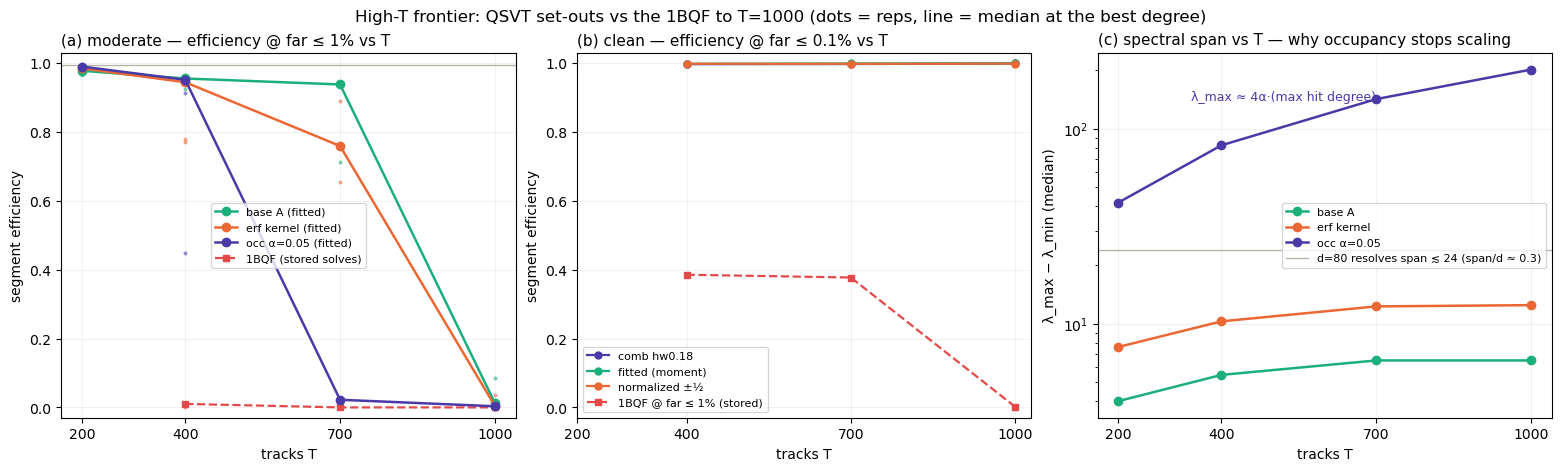

moderate, median eff @ far<=1% (fitted at best degree):


T,200,400,700,1000
setout,,,,
base,0.9783,0.9559,0.9385,0.0128
erf,0.9853,0.9450,0.7598,0.0043
occ_a0.05,0.9905,0.9522,0.0222,0.0033


1BQF reference (median):


eff_f010  far_e990
regime   T                       
clean    400     0.3856    0.4330
         700     0.3775    0.3972
         1000    0.0024    0.9637
moderate 400     0.0101    0.8694
         700     0.0000    0.9844
         1000    0.0000    0.9969

In [7]:
fh, bref = load("03_highT_frontier.csv"), load("03_1bqf_reference.csv")
if fh is None:
    print("high-T extension not yet produced — run 03_highT_frontier.py")
else:
    fh = fh[fh.family != "classical_invA"].copy()
    fh["degree"] = pd.to_numeric(fh["degree"], errors="coerce")
    f2h = load("02_setout_frontier.csv")
    f2h = f2h[(f2h.family != "classical_invA")
              & f2h.setout.isin(["base", "occ_a0.05", "erf"])].copy()
    f2h["degree"] = pd.to_numeric(f2h["degree"], errors="coerce")
    alld = pd.concat([f2h, fh], ignore_index=True)

    SET_COL = {"base": "#1baf7a", "occ_a0.05": "#4a3aa7", "erf": "#eb6834"}
    SET_LAB = {"base": "base A (fitted)", "occ_a0.05": "occ α=0.05 (fitted)",
               "erf": "erf kernel (fitted)"}
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), constrained_layout=True)

    # (a) moderate: fitted family at its best degree per (T, setout)
    ax = axes[0]
    mod = alld[(alld.regime == "moderate") & (alld.family == "fitted_moment")]
    for st, sg in mod.groupby("setout"):
        med = (sg.groupby(["T", "degree"])["eff_f010"].median().reset_index())
        best = med.loc[med.groupby("T")["eff_f010"].idxmax()]
        for _, r in best.iterrows():
            reps = sg[(sg["T"] == r["T"]) & (sg.degree == r.degree)]["eff_f010"]
            ax.plot([r["T"]] * len(reps), reps, ".", ms=4, alpha=0.45,
                    color=SET_COL[st], zorder=2)
        ax.plot(best["T"], best["eff_f010"], "o-", lw=1.8, ms=6,
                color=SET_COL[st], label=SET_LAB[st], zorder=3)
    if bref is not None:
        bb = bref[bref.regime == "moderate"]
        bm = bb.groupby("T")["eff_f010"].median()
        ax.plot(bm.index, bm.values, "s--", lw=1.6, ms=5,
                color=FAM_COL["1bqf_cos"], label="1BQF (stored solves)")
        ax.plot(bb["T"], bb["eff_f010"], ".", ms=4, alpha=0.4,
                color=FAM_COL["1bqf_cos"])
    ax.axhline(0.995, color="#b7b3a8", lw=1, zorder=0)
    ax.set_title("(a) moderate — efficiency @ far ≤ 1% vs T", loc="left",
                 fontsize=11)
    ax.set_ylim(-0.03, 1.03)

    # (b) clean: base families + 1BQF
    ax = axes[1]
    CLF = ["comb_prod", "fitted_moment", "normalized_half_comb"]
    cl = alld[(alld.regime == "clean") & (alld.setout == "base")]
    for fam in CLF:
        sg = cl[cl.family == fam]
        if not len(sg):
            continue
        med = sg.groupby(["T", "degree"])["eff_f001"].median().reset_index()
        best = med.loc[med.groupby("T")["eff_f001"].idxmax()]
        ax.plot(best["T"], best["eff_f001"], "o-", lw=1.6, ms=5,
                color=FAM_COL[fam], label=FAM_LAB[fam])
    if bref is not None:
        bb = bref[bref.regime == "clean"]
        bm = bb.groupby("T")["eff_f010"].median()
        ax.plot(bm.index, bm.values, "s--", lw=1.6, ms=5,
                color=FAM_COL["1bqf_cos"], label="1BQF @ far ≤ 1% (stored)")
    ax.set_title("(b) clean — efficiency @ far ≤ 0.1% vs T", loc="left",
                 fontsize=11)
    ax.set_ylim(-0.03, 1.03)

    # (c) the occupancy mechanism: spectral span vs T (resolution ∝ d/span)
    ax = axes[2]
    modall = alld[alld.regime == "moderate"]
    for st, sg in modall.groupby("setout"):
        sp = (sg.assign(span=sg.lam_max - sg.lam_min)
                .groupby("T")["span"].median())
        ax.plot(sp.index, sp.values, "o-", lw=1.8, ms=6, color=SET_COL[st],
                label=SET_LAB[st].replace(" (fitted)", ""))
    ax.axhline(80 * 0.30, color="#b7b3a8", lw=1,
               label="d=80 resolves span ≲ 24 (span/d ≈ 0.3)")
    ax.set_yscale("log")
    ax.set_title("(c) spectral span vs T — why occupancy stops scaling",
                 loc="left", fontsize=11)
    ax.set_ylabel("λ_max − λ_min (median)")
    ax.annotate("λ_max ≈ 4α·(max hit degree)", xy=(700, 140), fontsize=9,
                color=SET_COL["occ_a0.05"], ha="right")

    for ax, ylab in zip(axes, ["segment efficiency", "segment efficiency",
                               "λ_max − λ_min (median)"]):
        ax.set_xlabel("tracks T")
        ax.set_ylabel(ylab)
        ax.set_xticks([200, 400, 700, 1000])
        ax.grid(alpha=0.25, lw=0.5)
        ax.legend(fontsize=8, loc="best")
    fig.suptitle("High-T frontier: QSVT set-outs vs the 1BQF to T=1000 "
                 "(dots = reps, line = median at the best degree)", fontsize=12)
    plt.show()

    print("moderate, median eff @ far<=1% (fitted at best degree):")
    piv = (mod.groupby(["setout", "T", "degree"])["eff_f010"].median()
              .reset_index())
    piv = piv.loc[piv.groupby(["setout", "T"])["eff_f010"].idxmax()]
    display(piv.pivot_table(index="setout", columns="T",
                            values="eff_f010").round(4))
    if bref is not None:
        print("1BQF reference (median):")
        display(bref.groupby(["regime", "T"])[["eff_f010", "far_e990"]]
                .median().round(4))

## Best-case segment-level metrics — the QSVT envelope

The best QSVT configuration (over every set-out × family × degree, median across reps) per
regime and T, read three ways: **(a)** the most efficiency money can buy at a fixed
false-rate budget; **(b)** the best rejection factor at fixed efficiency targets (the
wp-style read — this is where the old "eff 0.99" headlines live, at whatever far that
costs); **(c)** the full efficiency-vs-rejection frontier of the per-T winner on moderate,
with both conventions marked on the same curve — the two readings are one object.
Winner annotations in (a) name the config. QSVT families only.

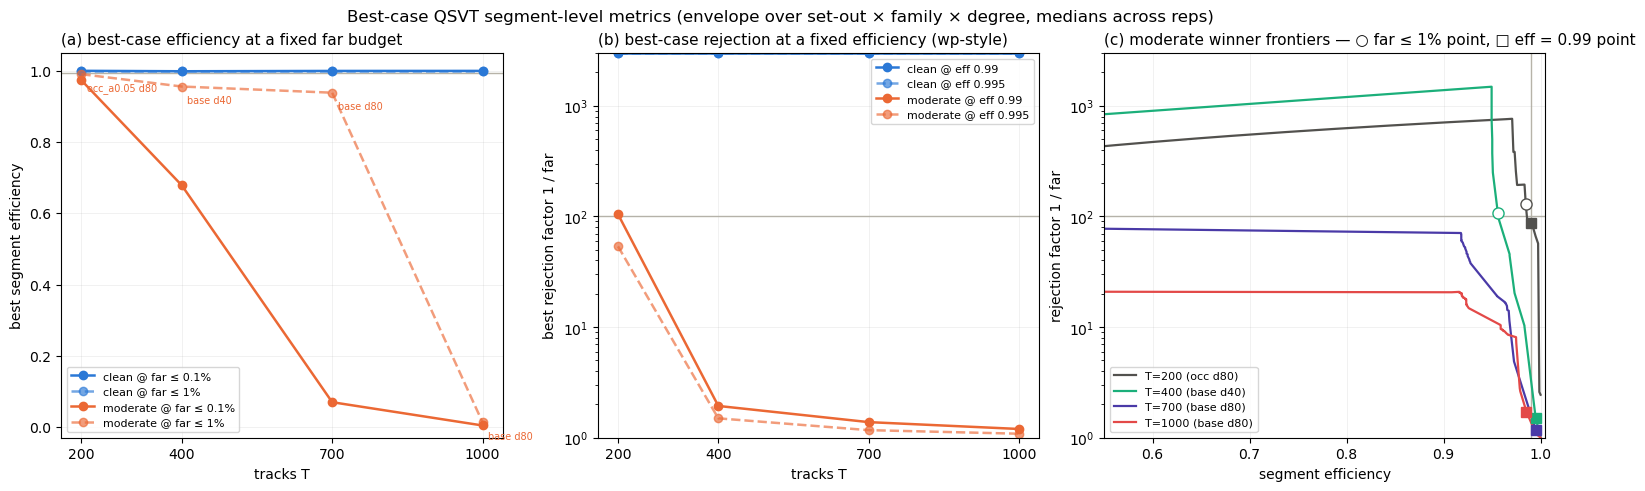

best-case table (moderate): eff@far≤1% and far@eff=0.99, per T


,T,setout_effbest,family_effbest,degree_effbest,eff_f010,setout_farbest,family_farbest,degree_farbest,far_e990
0,200,occ_a0.05,fitted_moment,80.0,0.9905,occ_a0.10,fitted_moment,160.0,0.0096
1,400,base,fitted_moment,40.0,0.9559,occ_a0.05,fitted_moment,80.0,0.5161
2,700,base,fitted_moment,80.0,0.9385,occ_a0.05,fitted_moment,80.0,0.7229
3,1000,base,fitted_moment,80.0,0.0128,occ_a0.05,fitted_moment,80.0,0.8337


In [8]:
srcs = []
for fn in ["01_frontier_clean_moderate.csv", "02_setout_frontier.csv",
           "03_highT_frontier.csv"]:
    df = load(fn)
    if df is not None:
        if "setout" not in df.columns:
            df = df.assign(setout="base")
        srcs.append(df)
if not srcs:
    print("no frontier CSVs yet")
else:
    env = pd.concat(srcs, ignore_index=True)
    env = env[~env.family.isin(["classical_invA", "1bqf_cos", "onebqf"])].copy()
    env["degree"] = pd.to_numeric(env["degree"], errors="coerce")
    med = (env.groupby(["regime", "T", "setout", "family", "degree"],
                       dropna=False)
              [["eff_f001", "eff_f010", "far_e990", "far_e995"]]
              .median().reset_index())
    REG_COL = {"clean": "#2a78d6", "moderate": "#eb6834"}
    REJ_CAP = 3e3

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)

    # (a) best efficiency at fixed far budgets
    ax = axes[0]
    for rg, col, ls, lab in [("clean", "eff_f001", "-", "clean @ far ≤ 0.1%"),
                             ("clean", "eff_f010", "--", "clean @ far ≤ 1%"),
                             ("moderate", "eff_f001", "-",
                              "moderate @ far ≤ 0.1%"),
                             ("moderate", "eff_f010", "--",
                              "moderate @ far ≤ 1%")]:
        sub = med[med.regime == rg]
        if not len(sub):
            continue
        best = sub.loc[sub.groupby("T")[col].idxmax()]
        ax.plot(best["T"], best[col], "o" + ls, lw=1.8, ms=6,
                color=REG_COL[rg], alpha=1.0 if ls == "-" else 0.65, label=lab)
        if rg == "moderate" and col == "eff_f010":
            for _, r in best.iterrows():
                dtxt = "" if pd.isna(r.degree) else f" d{int(r.degree)}"
                ax.annotate(f"{r.setout}{dtxt}", (r["T"], r[col]),
                            textcoords="offset points", xytext=(4, -12),
                            fontsize=7, color=REG_COL[rg])
    ax.axhline(0.995, color="#b7b3a8", lw=1, zorder=0)
    ax.set_ylim(-0.03, 1.05)
    ax.set_ylabel("best segment efficiency")
    ax.set_title("(a) best-case efficiency at a fixed far budget", loc="left",
                 fontsize=11)

    # (b) best rejection factor at fixed efficiency targets
    ax = axes[1]
    for rg in ("clean", "moderate"):
        sub = med[med.regime == rg]
        if not len(sub):
            continue
        for col, ls, lab in [("far_e990", "-", f"{rg} @ eff 0.99"),
                             ("far_e995", "--", f"{rg} @ eff 0.995")]:
            best = sub.loc[sub.groupby("T")[col].idxmin()]
            rej = 1.0 / np.maximum(best[col].values, 1.0 / REJ_CAP)
            ax.plot(best["T"], rej, "o" + ls, lw=1.8, ms=6, color=REG_COL[rg],
                    alpha=1.0 if ls == "-" else 0.65, label=lab)
    ax.axhline(100, color="#b7b3a8", lw=1, zorder=0)
    ax.set_yscale("log")
    ax.set_ylim(1, REJ_CAP)
    ax.set_ylabel("best rejection factor 1 / far")
    ax.set_title("(b) best-case rejection at a fixed efficiency (wp-style)",
                 loc="left", fontsize=11)

    # (c) frontier curves of the per-T moderate winner, both conventions marked
    ax = axes[2]
    T_COL = {200: "#52514e", 400: "#1baf7a", 700: "#4a3aa7", 1000: "#e34948"}
    WINNERS = {200: ("02_amps_occ_a0.05_rep0.npz", "fitted_moment_d80",
                     "occ d80"),
               400: ("03_amps_base_T400_rep0.npz", "fitted_moment_d40",
                     "base d40"),
               700: ("03_amps_base_T700_rep0.npz", "fitted_moment_d80",
                     "base d80"),
               1000: ("03_amps_base_T1000_rep0.npz", "fitted_moment_d80",
                      "base d80")}
    for T, (fn, key, lab) in WINNERS.items():
        p = CACHE / fn
        if not p.exists():
            continue
        z = np.load(p)
        if key not in z.files:
            continue
        e, r = rejection_curve(z[key], z["truth"])
        ax.plot(e, r, lw=1.6, color=T_COL[T], label=f"T={T} ({lab})")
        far = 1.0 / np.maximum(r, 1e-12)
        ok = far <= 0.01                       # the far ≤ 1% budget point
        if ok.any():
            i = int(np.argmax(np.where(ok, e, -1)))
            ax.plot([e[i]], [r[i]], "o", ms=8, mfc="white", color=T_COL[T],
                    zorder=4)
        j = int(np.argmin(np.abs(e - 0.99)))   # the wp-style eff 0.99 point
        ax.plot([e[j]], [r[j]], "s", ms=7, color=T_COL[T], zorder=4)
    ax.axhline(100, color="#b7b3a8", lw=1, zorder=0)
    ax.axvline(0.99, color="#b7b3a8", lw=1, zorder=0)
    ax.set_yscale("log")
    ax.set_xlim(0.55, 1.005)
    ax.set_ylim(1, REJ_CAP)
    ax.set_xlabel("segment efficiency")
    ax.set_ylabel("rejection factor 1 / far")
    ax.set_title("(c) moderate winner frontiers — ○ far ≤ 1% point, "
                 "□ eff = 0.99 point", loc="left", fontsize=11)

    for ax in axes[:2]:
        ax.set_xlabel("tracks T")
        ax.set_xticks([200, 400, 700, 1000])
    for ax in axes:
        ax.grid(alpha=0.25, lw=0.5)
        ax.legend(fontsize=8, loc="best")
    fig.suptitle("Best-case QSVT segment-level metrics (envelope over set-out × "
                 "family × degree, medians across reps)", fontsize=12)
    plt.show()

    print("best-case table (moderate): eff@far≤1% and far@eff=0.99, per T")
    sub = med[med.regime == "moderate"]
    ta = sub.loc[sub.groupby("T")["eff_f010"].idxmax(),
                 ["T", "setout", "family", "degree", "eff_f010"]]
    tb = sub.loc[sub.groupby("T")["far_e990"].idxmin(),
                 ["T", "setout", "family", "degree", "far_e990"]]
    display(ta.merge(tb, on="T", suffixes=("_effbest", "_farbest")).round(4))

## Canonical segment-level metrics vs T — the production comb from the store

The house segment-level metrics (Notion wp99-convention page / Source-of-Truth §6.5):
**segment efficiency** = n_true_active / n_true, **segment purity** = n_true_active /
n_active, **segment false rate** = n_false_active / n_active. Config = the programme's
best *fixed* parameter set for efficiency: production line-comb inverse **d = 40**, γ = 3,
δ = 1, step kernel, **ε = 2 mrad, clean events** — the stored campaign, T = 10 → 1000
(no new solves; same rows as the Notion headline table).

**Both operating-point conventions are shown.** The 2026-06-14 locked convention reads the
comb at the fixed cut τ = 0.35 (solid) — that is what the canonical headline table uses.
The per-solver-threshold principle ("never judge a quantum solver at the classical cut")
instead reads it at its own efficiency-first wp99 (dashed, store `_wp` columns). They
agree to T ≈ 200; beyond, the two conventions trade the same loss differently: fixed-τ
pays efficiency (0.970 → 0.922 at T = 400 → 1000, far ≤ 1 %), wp99 pays false rate
(eff pinned 0.99, far 0.014 → 0.202). The gap between the dashed and solid curves is the
tangle-true population drifting below 0.35 — recoverable by lowering τ, at the false-rate
price wp99 shows. The Efficiency_Frontier stages avoid the choice entirely by reporting
threshold-free matched-eff frontiers.

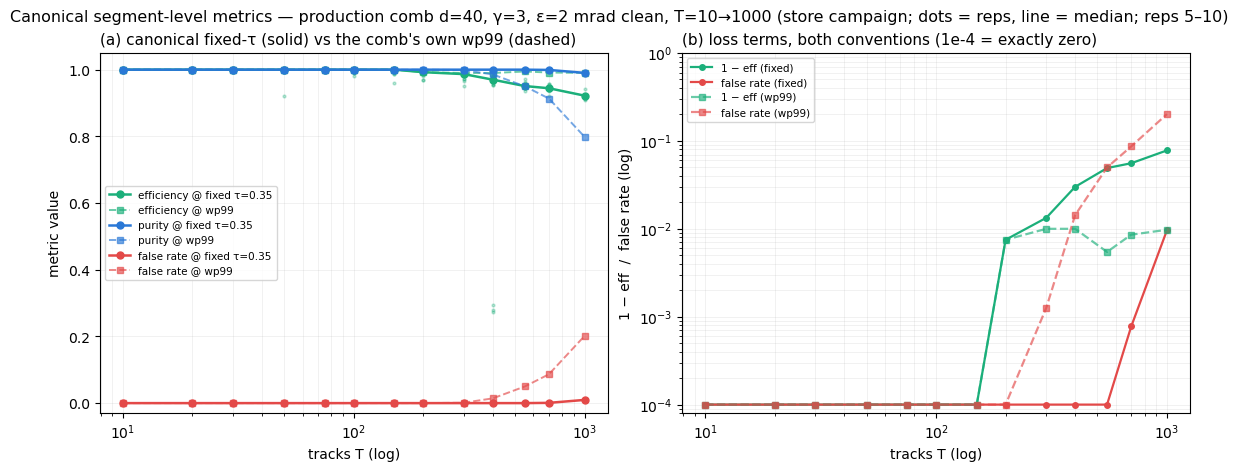

,segment_efficiency,segment_false_rate,segment_efficiency_wp,segment_false_rate_wp
n_trk,,,,
10,1.0000,0.0000,1.0000,0.0000
20,1.0000,0.0000,1.0000,0.0000
30,1.0000,0.0000,1.0000,0.0000
50,1.0000,0.0000,1.0000,0.0000
75,1.0000,0.0000,1.0000,0.0000
100,1.0000,0.0000,1.0000,0.0000
150,1.0000,0.0000,1.0000,0.0000
200,0.9925,0.0000,0.9925,0.0000
300,0.9867,0.0000,0.9900,0.0013


In [9]:
STORE_METRICS = Path("/data/bfys/gscriven/qtrk_store/manifest/metrics.csv")
if not STORE_METRICS.exists():
    print("store metrics view not found")
else:
    sm = pd.read_csv(STORE_METRICS)
    q = sm[(sm.solver == "qsvt") & (sm.gamma == 3.0) & (sm.sigma_res == 0.0)
           & (sm.hit_ineff == 0.0) & (sm.sigma_scatt == 1e-4)
           & np.isclose(sm.epsilon, 0.002, atol=1e-5)].copy()
    METS = [("segment_efficiency", "efficiency", "#1baf7a"),
            ("segment_purity", "purity", "#2a78d6"),
            ("segment_false_rate", "false rate", "#e34948")]
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)

    # (a) both conventions: fixed τ=0.35 (locked 2026-06-14) solid,
    #     the comb's own wp99 working point dashed
    ax = axes[0]
    for col, lab, c in METS:
        med = q.groupby("n_trk")[col].median()
        ax.plot(q["n_trk"], q[col], ".", ms=4, alpha=0.3, color=c, zorder=2)
        ax.plot(med.index, med.values, "o-", lw=1.8, ms=5, color=c,
                label=f"{lab} @ fixed τ=0.35", zorder=3)
        wcol = col + "_wp"
        if wcol in q.columns:
            wmed = q.groupby("n_trk")[wcol].median()
            ax.plot(wmed.index, wmed.values, "s--", lw=1.4, ms=4, color=c,
                    alpha=0.65, label=f"{lab} @ wp99", zorder=3)
    ax.set_xscale("log")
    ax.set_ylim(-0.03, 1.05)
    ax.set_xlabel("tracks T (log)")
    ax.set_ylabel("metric value")
    ax.set_title("(a) canonical fixed-τ (solid) vs the comb's own wp99 "
                 "(dashed)", loc="left", fontsize=11)
    ax.legend(fontsize=7.5, loc="center left", ncol=1)

    # (b) the loss terms, log scale, both conventions
    ax = axes[1]
    for col, base_lab, c, conv in [
            ("segment_efficiency", "1 − eff", "#1baf7a", "fixed"),
            ("segment_false_rate", "false rate", "#e34948", "fixed"),
            ("segment_efficiency_wp", "1 − eff", "#1baf7a", "wp99"),
            ("segment_false_rate_wp", "false rate", "#e34948", "wp99")]:
        if col not in q.columns:
            continue
        med = q.groupby("n_trk")[col].median()
        y = (1.0 - med.values) if col.startswith("segment_efficiency") \
            else med.values
        ls, al = ("o-", 1.0) if conv == "fixed" else ("s--", 0.65)
        ax.plot(med.index, np.clip(y, 1e-4, None), ls, lw=1.6, ms=4,
                color=c, alpha=al, label=f"{base_lab} ({conv})")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(8e-5, 1)
    ax.set_xlabel("tracks T (log)")
    ax.set_ylabel("1 − eff  /  false rate (log)")
    ax.set_title("(b) loss terms, both conventions (1e-4 = exactly zero)",
                 loc="left", fontsize=11)
    ax.legend(fontsize=7.5, loc="upper left")

    for ax in axes:
        ax.grid(alpha=0.25, lw=0.5, which="both")
    n_reps = q.groupby("n_trk")["rep"].nunique()
    fig.suptitle("Canonical segment-level metrics — production comb d=40, γ=3, "
                 "ε=2 mrad clean, T=10→1000 (store campaign; dots = reps, "
                 f"line = median; reps {n_reps.min()}–{n_reps.max()})",
                 fontsize=11.5)
    plt.show()

    cols = ["segment_efficiency", "segment_false_rate",
            "segment_efficiency_wp", "segment_false_rate_wp"]
    cols = [c for c in cols if c in q.columns]
    display(q.groupby("n_trk")[cols].median().round(4))

## Stage 3 — heavy quantum-only frontier + the L1–L3 loss budget

The decisive stage. **Scope (George, 2026-08-25): quantum-only** — no gate, no composed
points; the reference to beat is the XII fitted response (far 0.061–0.096 @ matched eff
0.97–0.98).

The budget converts "the filter loses 2 %" into *which* 2 %. At each config's far ≤ 1 %
operating point every missed true segment is attributed to exactly one channel
(L1+L2+L3+eff = 1 by construction):

- **L1 twins — irreducible.** Floor theorem: `f(PAP^T)b = P f(A)b` for *every* f, so a true
  segment in a component isomorphic to a false one gets an identical amplitude under every
  response. Detected as a multi-response fingerprint match (K independent probes).
- **L2 ripple — fixable by degree**: recovered by another degree of the same family.
- **L3 overlap — fixable by a better response/operator**: not a twin, no degree recovers it.

Panel (b) is the mechanism: **the twin fraction is a property of the operator, not the
response** — so the only way to move L1 is to change A.

heavy frontier — median far at matched eff, best degree per family


,setout,family,degree,far_e980,far_e990,eff_f010
5,base,fitted_moment,160.0,0.0771,0.6332,0.9283
21,occ_a0.05,fitted_moment,160.0,0.0867,0.3558,0.9349
27,occ_a0.10,fitted_moment,80.0,0.0919,0.3808,0.4412
10,erf,fitted_moment,40.0,0.3502,0.7472,0.8564
15,erf,normalized_half_comb,44.0,0.5814,0.9000,0.0000
7,base,normalized_half_comb,44.0,0.6191,0.6405,0.0038
17,occ_a0.05,comb_prod,44.0,0.6520,0.9778,0.0000
24,occ_a0.10,comb_prod,40.0,0.6609,0.9855,0.0000
30,occ_a0.10,normalized_half_comb,40.0,0.9949,0.9949,0.0000
22,occ_a0.05,normalized_half_comb,40.0,0.9949,0.9949,0.0000


classical reference far@eff0.98 = 0.1252  (XII quantum-only reference: 0.061-0.096 @ eff 0.97-0.98)


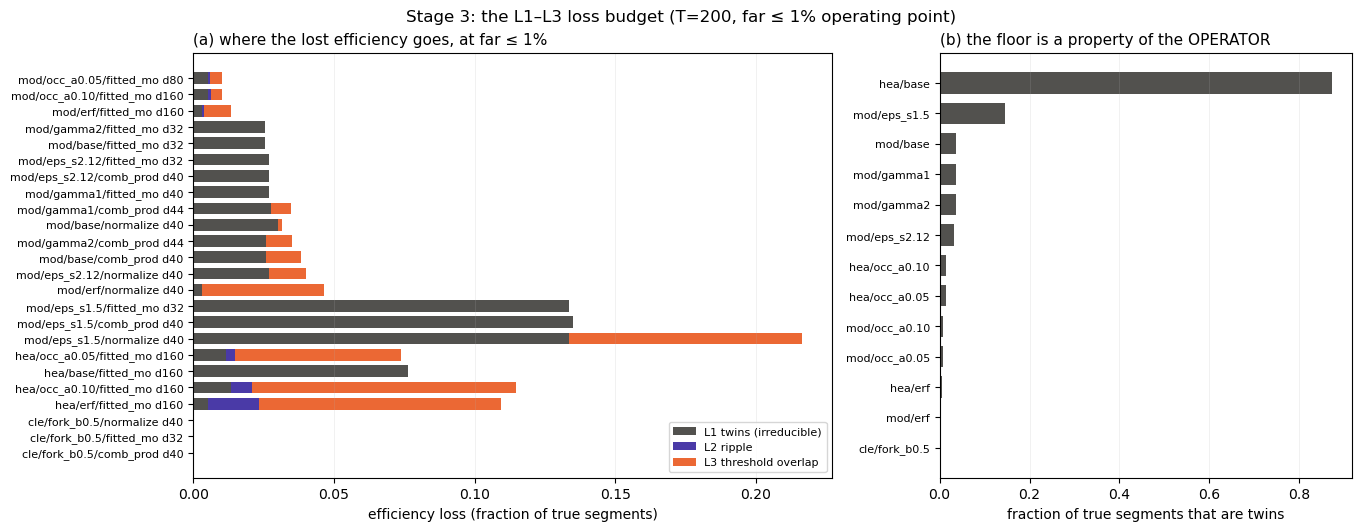

identity check  max|L1+L2+L3+eff-1| = 4.44e-16


In [10]:
f3, f4 = load("04_heavy_frontier.csv"), load("05_loss_budget.csv")
if f3 is not None:
    print("heavy frontier — median far at matched eff, best degree per family")
    g = (f3[f3.family != "classical_invA"]
         .groupby(["setout", "family", "degree"])[["far_e980", "far_e990", "eff_f010"]]
         .median().reset_index())
    display(g.loc[g.groupby(["setout", "family"]).far_e980.idxmin()]
            .sort_values("far_e980").round(4))
    cls = f3[f3.family == "classical_invA"].far_e980.median()
    print(f"classical reference far@eff0.98 = {cls:.4f}  "
          f"(XII quantum-only reference: 0.061-0.096 @ eff 0.97-0.98)")
else:
    print("Stage 3 heavy frontier not yet produced")

if f4 is None:
    print("Stage 3 loss budget not yet produced — the central deliverable")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True,
                             gridspec_kw={"width_ratios": [1.55, 1]})
    # (a) stacked budget for the best config per (regime, setout, family)
    g = (f4.groupby(["regime", "setout", "family", "degree"])
           [["eff", "L1", "L2", "L3"]].median().reset_index())
    best = g.loc[g.groupby(["regime", "setout", "family"]).eff.idxmax()]
    best = best[best.eff > 0.5].sort_values(["regime", "eff"])
    lab = [f"{r.regime[:3]}/{r.setout}/{r.family.replace('_half_comb','')[:9]} d{r.degree:.0f}"
           for _, r in best.iterrows()]
    y = np.arange(len(best))
    left = np.zeros(len(best))
    for ch, col in [("L1", "#52514e"), ("L2", "#4a3aa7"), ("L3", "#eb6834")]:
        axes[0].barh(y, best[ch], left=left, color=col, height=0.72,
                     label={"L1": "L1 twins (irreducible)", "L2": "L2 ripple",
                            "L3": "L3 threshold overlap"}[ch])
        left += best[ch].values
    axes[0].set_yticks(y); axes[0].set_yticklabels(lab, fontsize=8)
    axes[0].set_xlabel("efficiency loss (fraction of true segments)")
    axes[0].set_title("(a) where the lost efficiency goes, at far ≤ 1%",
                      loc="left", fontsize=11)
    axes[0].legend(fontsize=8, loc="lower right"); axes[0].grid(alpha=0.25, lw=0.5, axis="x")
    # (b) twin fraction = the response-independent floor, per set-out
    tw = f4.groupby(["regime", "setout"]).twin_frac.median().reset_index()
    tw = tw.sort_values("twin_frac")
    axes[1].barh(np.arange(len(tw)), tw.twin_frac, color="#52514e", height=0.7)
    axes[1].set_yticks(np.arange(len(tw)))
    axes[1].set_yticklabels([f"{r.regime[:3]}/{r.setout}" for _, r in tw.iterrows()],
                            fontsize=8)
    axes[1].set_xlabel("fraction of true segments that are twins")
    axes[1].set_title("(b) the floor is a property of the OPERATOR", loc="left",
                      fontsize=11)
    axes[1].grid(alpha=0.25, lw=0.5, axis="x")
    fig.suptitle("Stage 3: the L1–L3 loss budget (T=200, far ≤ 1% operating point)",
                 fontsize=12)
    plt.show()
    print("identity check  max|L1+L2+L3+eff-1| = "
          f"{(f4.L1 + f4.L2 + f4.L3 + f4.eff - 1).abs().max():.2e}")

## Stage 4 — T=400 confirmation (auto-loads when produced)

In [11]:
f5 = load("06_confirmation.csv")
display(f5.head(20)) if f5 is not None else print("Stage 4 not yet produced")

Stage 4 not yet produced


## Segment-level metrics — the answer to the study's question

George (2026-08-26): *"1BQF, HHL and classical can get >95 % segment efficiency, but at the cost
of an exploding false rate. The question is: by adjusting the polynomial, or by adjusting the
Hamiltonian (which means refitting the polynomial) with occupancy and bifurcation terms, is
there a noticeable improvement in segment efficiency?"*

Presented as the QSVT III segment-metric pair (`wp1_fixed_tau` / `wp1_working_points`), with
the noise sweep replaced by this experiment's two axes:

- **(a) segment efficiency at a fixed false-rate budget (far ≤ 1 %)** — the efficiency you can
  actually buy at an affordable fake rate;
- **(b) segment false rate at the efficiency-first working point (eff = 0.99)** — what ≥99 %
  efficiency costs. This panel *is* the QSVT III working-point plot.

Classical inversion and the 1BQF are **reference lines**, not competing series — they are the
baseline the question is posed against. Source: `07_segment_metrics.py`;
numbers in `outputs/07_segment_metrics.csv`.

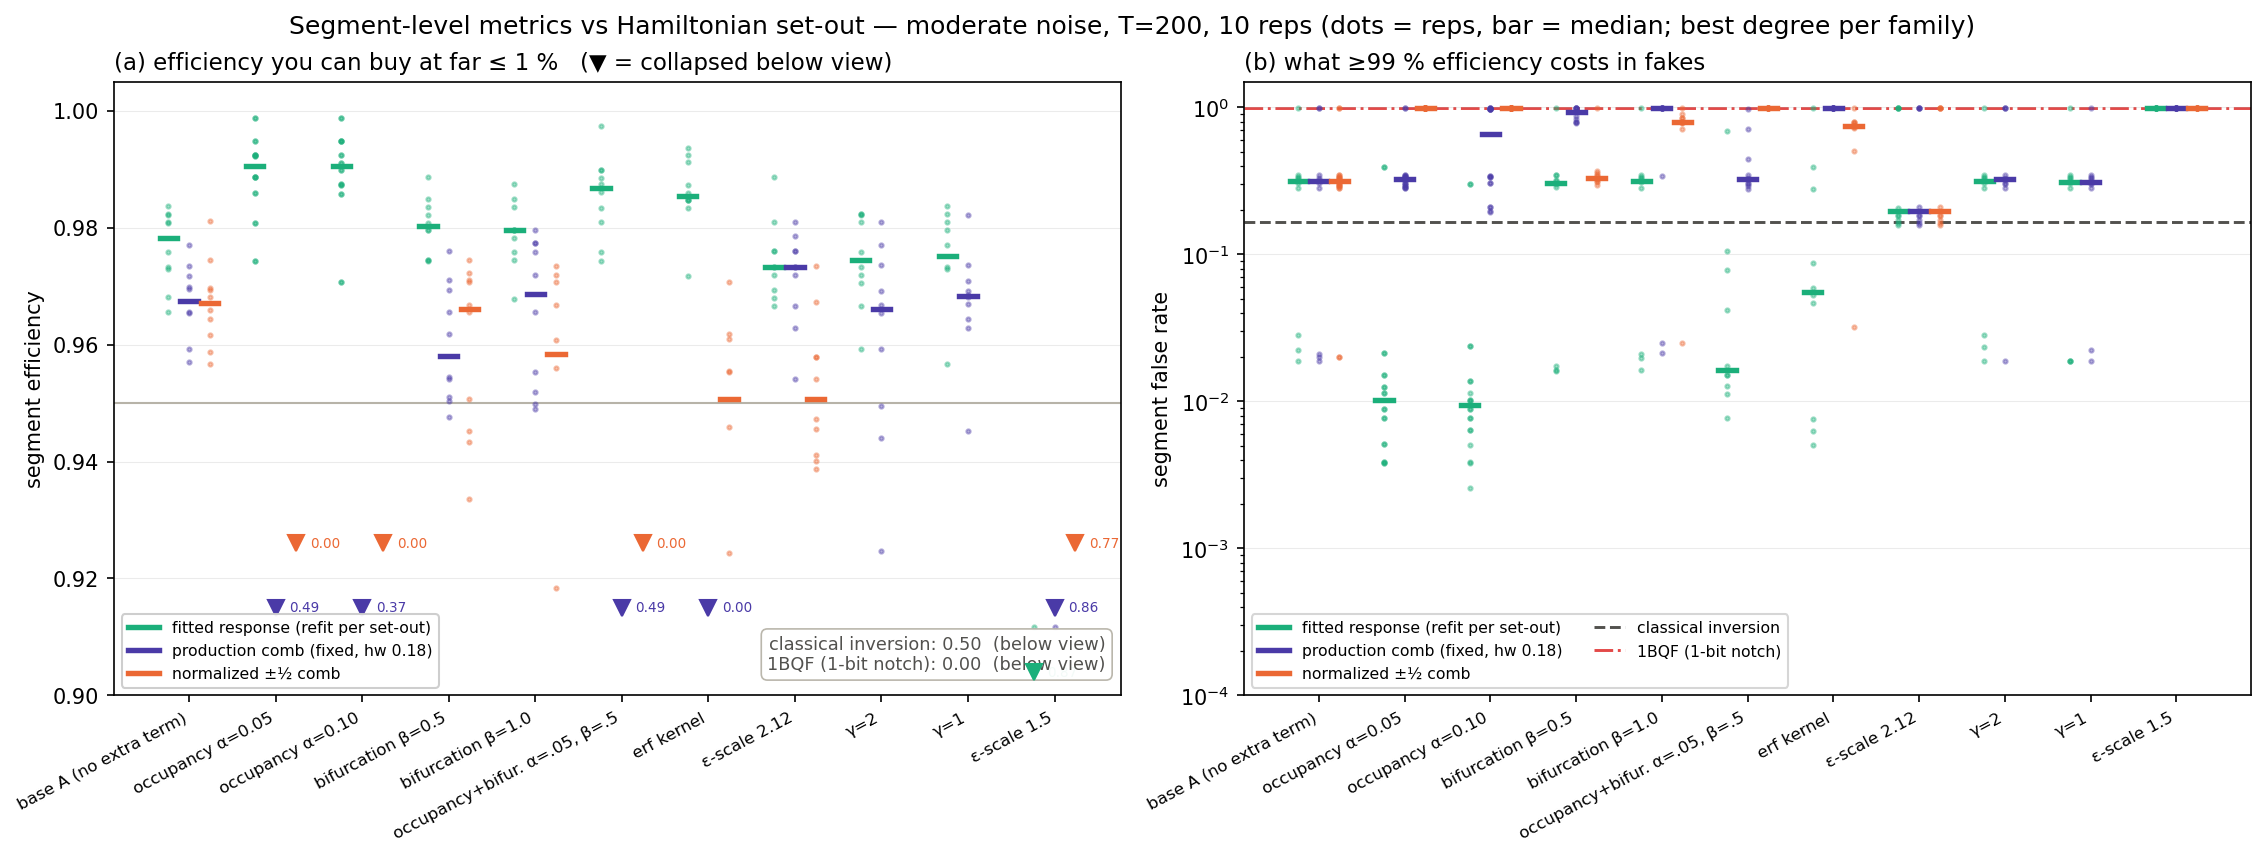

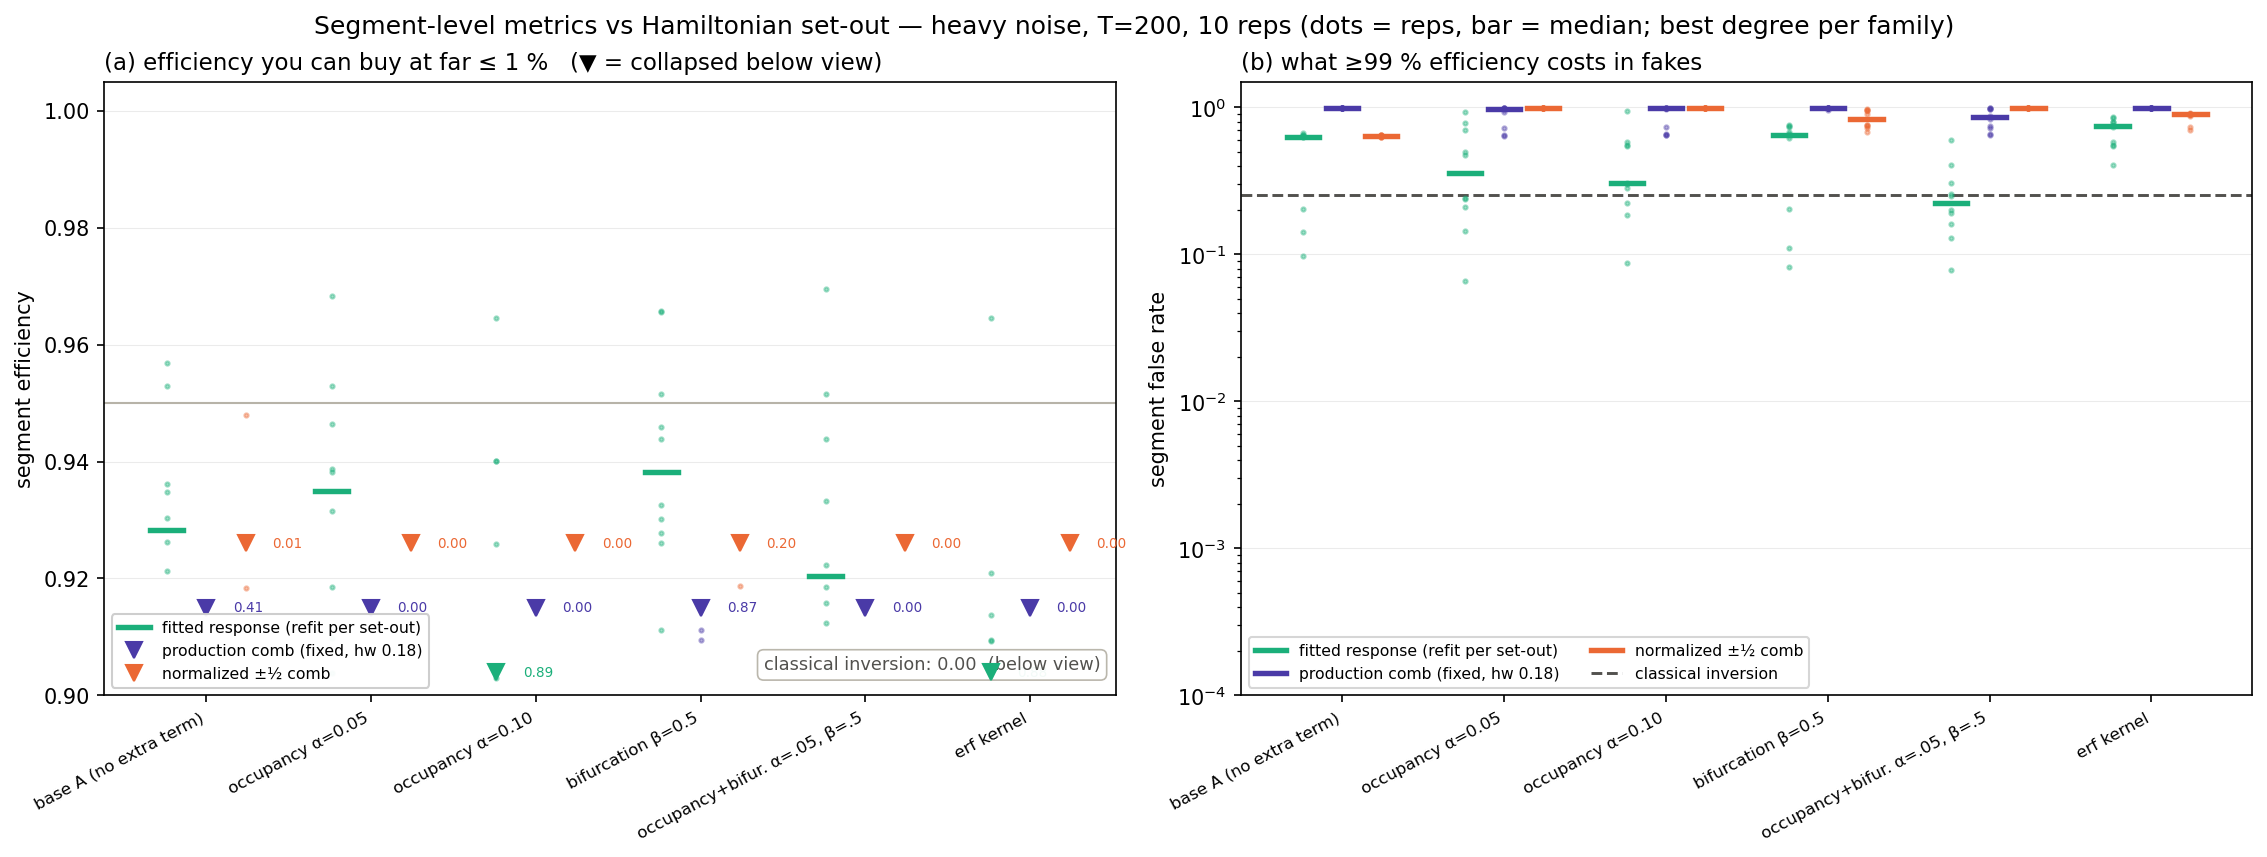


=== moderate T=200 — segment efficiency @ far<=1% | false rate @ eff 0.99 ===


,setout,family,eff_at_far1pct,best_d_eff,far_at_eff99,best_d_far
3,occ_a0.05,fitted,0.9905,80.0,0.0102,80.0
6,occ_a0.10,fitted,0.9905,160.0,0.0095,160.0
15,occ0.05_fork0.5,fitted,0.9867,80.0,0.0164,80.0
18,erf,fitted,0.9853,160.0,0.0559,160.0
9,fork_b0.5_mod,fitted,0.9802,32.0,0.3076,44.0
12,fork_b1.0_mod,fitted,0.9796,32.0,0.3161,32.0
0,base,fitted,0.9783,160.0,0.3137,80.0
26,gamma1,fitted,0.9751,44.0,0.3127,80.0
24,gamma2,fitted,0.9745,32.0,0.3137,32.0
21,eps_s2.12,fitted,0.9732,32.0,0.1968,32.0



=== heavy T=200 — segment efficiency @ far<=1% | false rate @ eff 0.99 ===


,setout,family,eff_at_far1pct,best_d_eff,far_at_eff99,best_d_far
42,fork_b0.5,fitted,0.9382,160.0,0.6533,160.0
36,occ_a0.05,fitted,0.9349,160.0,0.3558,160.0
33,base,fitted,0.9283,160.0,0.6331,84.0
45,occ0.05_fork0.5,fitted,0.9204,160.0,0.2248,160.0
39,occ_a0.10,fitted,0.8938,160.0,0.3042,160.0
48,erf,fitted,0.8792,160.0,0.7462,84.0
43,fork_b0.5,comb_prod,0.8663,40.0,0.9950,40.0
34,base,comb_prod,0.4089,44.0,0.9950,40.0
44,fork_b0.5,normalized_half_comb,0.1954,40.0,0.8308,44.0
35,base,normalized_half_comb,0.0051,40.0,0.6405,44.0


In [12]:
from IPython.display import Image, display
t = load("07_segment_metrics.csv")
for regime in ("moderate", "heavy"):
    p = HERE / "figures" / f"segment_metrics_setouts_{regime}.png"
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f"{p.name} not built — run 07_segment_metrics.py")
if t is not None:
    for regime in ("moderate", "heavy"):
        s = t[t.regime == regime].sort_values("eff_at_far1pct", ascending=False)
        print(f"\n=== {regime} T=200 — segment efficiency @ far<=1% | "
              f"false rate @ eff 0.99 ===")
        display(s[["setout", "family", "eff_at_far1pct", "best_d_eff",
                   "far_at_eff99", "best_d_far"]].head(12).round(4))